# **Phase 6: Decision Interpretability & Disagreement Analysis**
---
**Objective:** understand *why* the three decision systems disagree.
- Why does hybrid ≠ rule-only?
- Why does cluster-only fail in some cases?
- What are the features that push decisions from combustion → pyrolysis → further assessment?

In [2]:
import pandas as pd
import sys, os
sys.path.append(os.path.abspath(".."))

from src.analysis.disagreement_analysis import label_disagreement_cases
from src.analysis.feature_diagnostics import summarize_features_by_group

# Load final phase 5 output
df = pd.read_csv(
    "../data/processed/comparison_decisions.csv"
)

# Label disagreements
df = label_disagreement_cases(df)

# Save disagreement counts
disagreement_summary = df[
    [
        "Cluster_vs_Rule_Disagree",
        "Rule_vs_Hybrid_Disagree",
        "Cluster_vs_Hybrid_Disagree"
    ]
].mean()

disagreement_summary.to_csv(
    "../results/tables/phase6a_interpretability/disagreement_counts.csv"
)

disagreement_summary

Cluster_vs_Rule_Disagree      0.096296
Rule_vs_Hybrid_Disagree       0.148148
Cluster_vs_Hybrid_Disagree    0.074074
dtype: float64

In [3]:
df.to_csv(
    "../data/processed/disagreement_analysis.csv", index=False
)

In [4]:
# feature behaviour behind decisions
# Feature profiles by final hybrid decision
tech_profiles = summarize_features_by_group(
    df,
    "Final_Conversion_Technology"
)

tech_profiles.to_csv(
    "../results/tables/phase6a_interpretability/technology_feature_profiles.csv"
)

tech_profiles

Ash_db                  VM_db                 \
                               mean median     std    mean median     std   
Final_Conversion_Technology                                                 
Combustion                    1.300   1.30     NaN  97.800  97.80     NaN   
Further Assessment Needed    14.626   9.60  13.129  72.868  78.00  11.235   
Gasification                 41.583  42.05   8.682  47.083  50.85   8.692   
Pyrolysis                     3.547   1.60   5.690  79.888  80.70   6.535   

                              FC_db               Moist_ar  ... Silica_Ratio  \
                               mean median    std     mean  ...          std   
Final_Conversion_Technology                                 ...                
Combustion                    0.900   0.90    NaN    2.200  ...          NaN   
Further Assessment Needed    14.359  15.20  4.626   13.500  ...       39.102   
Gasification                 11.333  12.25  4.045   57.833  ...       11.832   
Pyrolysis                    16.568  16.90  3.768   18.810  ...       13.463   

                            Base_Acid_Ratio                 \
                                       mean median     std   
Final_Conversion_Technology                                  
Combustion                            2.531  2.531     NaN   
Further Assessment Needed             1.015  0.395   1.549   
Gasification                          0.512  0.438   0.467   
Pyrolysis                            15.262  6.051  21.804   

                            Energy_Density_Index                    \
                                            mean   median      std   
Final_Conversion_Technology                                          
Combustion                                36.540   36.540      NaN   
Further Assessment Needed                268.251  293.968  109.655   
Gasification                             138.733  130.392   53.556   
Pyrolysis                                321.127  323.400   87.197   

                            Combustibility_Index                    
                                            mean   median      std  
Final_Conversion_Technology                                         
Combustion                                28.108   28.108      NaN  
Further Assessment Needed                125.032   69.445  152.069  
Gasification                               3.622    2.805    2.091  
Pyrolysis                                    inf  224.166      NaN  

[4 rows x 27 columns]

**What does 'mean', 'median' and 'std' interpret**

| Metric | Explanation |
|---|---|
| mean | Typical fuel condition |
| median | If fuel behavior is widespread or driven by outliers |
| std | Confidence level of assigning a single technology |

_**What do fuels look like when clusters override rules and shifts the decision towards specific technology?**_

In [5]:
# focus only on disagreement samples
# Analyze only rule vs hybrid disagreements
# explains only those cases in datasets where adding cluster information chnaged the final technology (rule != hybrid)

disagree_df = df[df["Rule_vs_Hybrid_Disagree"]]

disagree_features = summarize_features_by_group(
    disagree_df,
    "Final_Conversion_Technology"
)

disagree_features.to_csv(
    "../results/tables/phase6a_interpretability/disagreement_feature_stats.csv"
)

disagree_features

Ash_db                 VM_db                \
                               mean median    std    mean median    std   
Final_Conversion_Technology                                               
Combustion                    1.300   1.30    NaN  97.800  97.80    NaN   
Further Assessment Needed     6.409   4.15  6.671  78.176  78.90  5.682   
Gasification                 41.583  42.05  8.682  47.083  50.85  8.692   
Pyrolysis                    28.333  26.20  3.782  59.733  58.80  4.081   

                              FC_db               Moist_ar  ... Silica_Ratio  \
                               mean median    std     mean  ...          std   
Final_Conversion_Technology                                 ...                
Combustion                    0.900   0.90    NaN    2.200  ...          NaN   
Further Assessment Needed    15.415  15.45  4.395      NaN  ...        1.359   
Gasification                 11.333  12.25  4.045   57.833  ...       11.832   
Pyrolysis                    11.933  11.10  2.843   12.233  ...       68.722   

                            Base_Acid_Ratio                \
                                       mean median    std   
Final_Conversion_Technology                                 
Combustion                            2.531  2.531    NaN   
Further Assessment Needed             2.555  2.555  2.973   
Gasification                          0.512  0.438  0.467   
Pyrolysis                             0.681  0.405  0.840   

                            Energy_Density_Index                   \
                                            mean   median     std   
Final_Conversion_Technology                                         
Combustion                                36.540   36.540     NaN   
Further Assessment Needed                287.914  296.291  92.924   
Gasification                             138.733  130.392  53.556   
Pyrolysis                                161.682  137.751  43.199   

                            Combustibility_Index                   
                                            mean  median      std  
Final_Conversion_Technology                                        
Combustion                                28.108  28.108      NaN  
Further Assessment Needed                137.346  82.470  154.405  
Gasification                               3.622   2.805    2.091  
Pyrolysis                                  5.833   5.181    2.027  

[4 rows x 27 columns]

In [6]:
disagree_df.head()

,Sample_ID,Biomass_Type,Class,Subclass,Ash_db,VM_db,FC_db,C_db,H_db,N_db,...,Cluster,Final_Tech_ClusterOnly,Primary_Process,Secondary_Process,Constraint_Level,Final_Tech_RuleOnly,Final_Conversion_Technology,Cluster_vs_Rule_Disagree,Rule_vs_Hybrid_Disagree,Cluster_vs_Hybrid_Disagree
1,3,Agricultural,Animal farming,Chicken manure pellets,32.7,56.2,11.1,30.0,3.91,3.94,...,2.0,Further Assessment Needed,Pre-treatment Required,NaN,Low,Further Assessment Needed,Pyrolysis,False,True,True
2,4,Urban Waste,Biosolids,Treated biosolids,42.8,52.0,5.2,24.7,4.35,4.61,...,2.0,Further Assessment Needed,Pre-treatment Required,NaN,High,Further Assessment Needed,Gasification,False,True,True
3,5,Industrial Processing,Paper industry,Paper sludge,26.2,64.2,9.6,32.4,4.96,0.47,...,2.0,Further Assessment Needed,Pre-treatment Required,NaN,Low,Further Assessment Needed,Pyrolysis,False,True,True
5,7,Industrial Processing,Rice industry,Rice hulls,26.1,58.8,15.1,31.1,4.59,0.27,...,2.0,Further Assessment Needed,Gasification,Combustion,Low,Gasification,Pyrolysis,True,True,True
6,8,Urban Waste,Green waste,Raw Green waste,53.5,33.5,13.0,21.7,2.37,1.85,...,2.0,Further Assessment Needed,Pre-treatment Required,NaN,High,Further Assessment Needed,Gasification,False,True,True


**Disagreements are in two regions:** 
1. `Cluster 2 fuels with high ash content` where rule-only suggest "further assessment" to most samples. However, hyrbrid model decides technology by using both fuel-typology and constraint level. _**Gassification**_ to high constraint sampels (very high ash and/or moisture) and _**Pyrolysis**_ to lower constraint samples (high ash)
2. `A small set of samples that lacks fuel-typology cluster` which is due to missing clustering-relevant features. Here, hybrid framework refers to "Further Assessment Needed" and do not rely only on rule-only logic with no typology content.

### **Visualization**
---

In [7]:
# import visualization functions
from src.visualization.disagreement_plots import (
    plot_boxplots,
    plot_violinplots,
    plot_scatter_boundary,
    plot_radar_chart
)

In [8]:
# load data
df_vis = pd.read_csv(
    "../data/processed/disagreement_analysis.csv"
)
# Focus only on disagreement cases
df_disagree = df_vis[df_vis["Rule_vs_Hybrid_Disagree"] == 1]

In [9]:
key_features = [
    "Ash_db",
    "VM_db",
    "Moist_ar",
    "Alkali_Index",
    "Silica_Ratio",
    "Base_Acid_Ratio",
    "Energy_Density_Index",
    "Combustibility_Index"
]

In [13]:
# boxplot
plot_boxplots(
    df=df_disagree,
    features=key_features,
    output_dir="../results/figures/phase6a_interpretability/boxplots"
)

In [10]:
# violin plots
plot_violinplots(
    df=df_disagree,
    features=key_features,
    output_dir="../results/figures/phase6a_interpretability/violin"
)

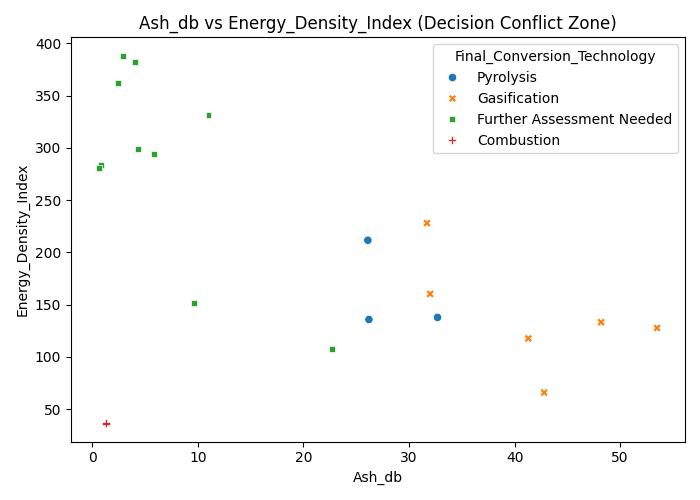

In [14]:
# scatter plots (boundary conflict)
from IPython.display import Image, display

plot_scatter_boundary(
    df=df_disagree,
    x_feature="Ash_db",
    y_feature="Energy_Density_Index",
    output_path="../results/figures/phase6a_interpretability/scatter/ash_vs_energy.png"
)
display(Image(filename="../results/figures/phase6a_interpretability/scatter/ash_vs_energy.png"))

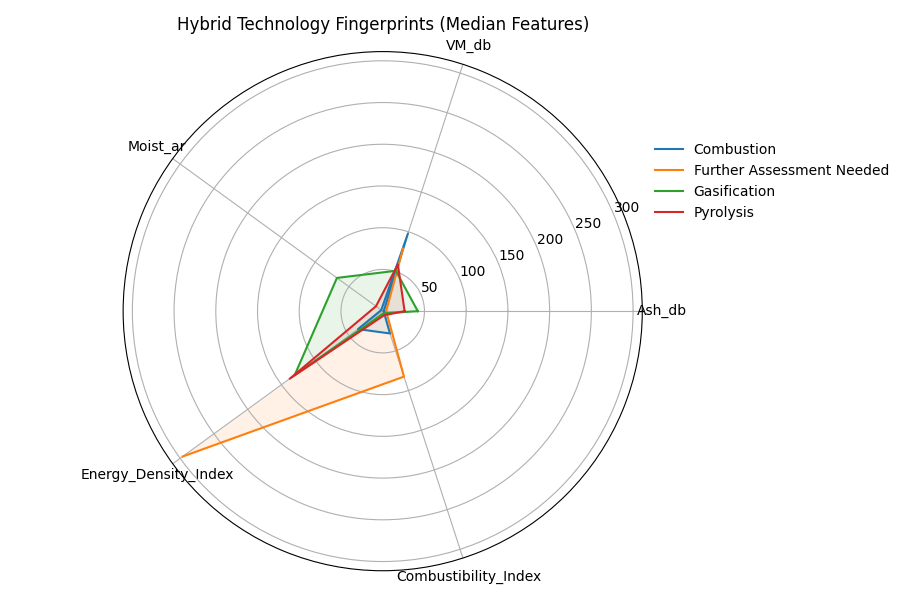

In [15]:
# Technology fingerprint (radar/spider chart)
radar_features = [
    "Ash_db",
    "VM_db",
    "Moist_ar",
    "Energy_Density_Index",
    "Combustibility_Index"
]
plot_radar_chart(
    df=df_disagree,
    features=radar_features,
    output_path="../results/figures/phase6a_interpretability/radar/technology_radar.png"
)
display(Image(filename="../results/figures/phase6a_interpretability/radar/technology_radar.png"))